# Paid Content Strategy Research

Date: 2026-05-20  
Feature idea: evaluate paid content for Vibe-to-MIDI, including paid content scope, sales model, Google Play Billing, external payment services, and additional risks to decide before implementation.

## Feature Hypothesis

- Idea: add a paid tier or paid content packs that deepen Vibe-to-MIDI's DAW-ready learning and generation workflow.
- Target user: Android-first electronic music learners and producers who want fast mood-to-MIDI guidance for dub techno / ambient / minimal electronic tracks.
- Problem: users may value more track types, deeper sound palettes, MIDI export, learning modules, and saved workflows, but payment design must comply with Google Play rules.
- MVP scope: one simple paid entitlement, likely Google Play Billing first, with content that clearly extends app value without blocking the free learning loop.
- Non-goals: marketplace for copyrighted sample packs, artist-style clones, subscription-heavy AI generation before retention is proven, and payment flows that risk Play policy violations.
- Research questions:
  - What content is worth charging for first?
  - Should monetization start as one-time product, subscription, or external checkout?
  - What does Google Play require for in-app digital goods?
  - Can Stripe or other external payment services be used safely?
  - What product, legal, and implementation risks should be handled before building?

## Source Notes

- Google Play Payments policy: https://support.google.com/googleplay/android-developer/answer/10281818 — Play Billing is required for in-app purchases of digital goods/services unless specific regional/program exceptions apply; India/South Korea alternatives reduce service fee by 4%; EEA and US have enrolled-program alternatives.
- Google Play one-time products: https://developer.android.com/google/play/billing/one-time-products — one-time products are single-charge digital items that grant permanent or non-renewable access.
- Google Play alternative billing APIs: https://developer.android.com/google/play/billing/alternative — eligible developers in certain countries can offer alternative billing with user choice or alternative billing, but must enroll and integrate reporting APIs.
- Google Play external payments Japan: https://developer.android.com/google/play/billing/externalpaymentlinks — Japan program allows external payment links for in-app digital items only with side-by-side Google Play Billing choice and Play Billing Library 8.3+.
- Expo IAP guide: https://docs.expo.dev/guides/in-app-purchases/ — Expo apps need development builds for native IAP; recommended libraries include react-native-purchases / RevenueCat and expo-iap.
- RevenueCat Expo docs: https://www.revenuecat.com/docs/getting-started/installation/expo — RevenueCat manages products, entitlements, offerings, paywalls, and store integrations from an Expo app.
- Stripe digital goods docs: https://docs.stripe.com/mobile/digital-goods — Stripe says Android apps in the US can process digital goods payments directly in-app with a third-party processor; policy eligibility and regional scope still need product/legal verification before use.
- Chordbot Google Play listing: https://play.google.com/store/apps/details?id=com.chordbot — adjacent Android music app sells as a paid app and offers chord progression creation plus MIDI/WAV export.
- OtoTheory product page: https://www.ototheory.com/ — adjacent theory/chord workflow offers Pro subscription on iOS with MIDI/audio/PDF export and offline/cloud features.
- Piano Companion product page: https://www.songtive.com/products/piano-companion/ — adjacent cross-platform theory app emphasizes large chord/scale library, progression builder, and MIDI keyboard support.

## Data / Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path('../figures')
fig_dir.mkdir(parents=True, exist_ok=True)

content_options = pd.DataFrame([
    {'content': 'Premium sound packs', 'user_value': 4, 'implementation_cost': 2, 'policy_risk': 2, 'notes': 'More dub techno variants: kicks, basses, stabs, space profiles; synthesis only, no samples.'},
    {'content': 'Track recipe packs', 'user_value': 5, 'implementation_cost': 2, 'policy_risk': 1, 'notes': 'More curated moods/seasons/club contexts with MIDI-ready notes, patterns, and mix.'},
    {'content': 'MIDI export', 'user_value': 5, 'implementation_cost': 3, 'policy_risk': 1, 'notes': 'High DAW value; clear paid upgrade candidate after internal MIDI data stabilizes.'},
    {'content': 'Advanced learning lessons', 'user_value': 4, 'implementation_cost': 3, 'policy_risk': 1, 'notes': 'Chord/scale/rhythm lessons with focused listening and comparison.'},
    {'content': 'Saved projects / library', 'user_value': 4, 'implementation_cost': 3, 'policy_risk': 1, 'notes': 'Save favorites, compare versions, recall track ideas.'},
    {'content': 'AI generation credits', 'user_value': 4, 'implementation_cost': 5, 'policy_risk': 3, 'notes': 'Potentially valuable but requires backend, cost controls, abuse prevention, and clearer AI scope.'},
    {'content': 'Sample packs', 'user_value': 3, 'implementation_cost': 4, 'policy_risk': 4, 'notes': 'Avoid for MVP due to licensing, storage, and copyright risk.'},
])
content_options['mvp_score'] = content_options['user_value'] * 2 - content_options['implementation_cost'] - content_options['policy_risk']
content_options.sort_values('mvp_score', ascending=False)


,content,user_value,implementation_cost,policy_risk,notes,mvp_score
1,Track recipe packs,5,2,1,More curated moods/seasons/club contexts with ...,7
2,MIDI export,5,3,1,High DAW value; clear paid upgrade candidate a...,6
0,Premium sound packs,4,2,2,"More dub techno variants: kicks, basses, stabs...",4
3,Advanced learning lessons,4,3,1,Chord/scale/rhythm lessons with focused listen...,4
4,Saved projects / library,4,3,1,"Save favorites, compare versions, recall track...",4
5,AI generation credits,4,5,3,"Potentially valuable but requires backend, cos...",0
6,Sample packs,3,4,4,"Avoid for MVP due to licensing, storage, and c...",-2


In [2]:
sales_models = pd.DataFrame([
    {'model': 'Free + one-time Pro unlock', 'fit': 5, 'complexity': 2, 'recurring_revenue': 1, 'policy_fit': 5, 'notes': 'Best MVP: unlock export, extra track recipes, advanced lessons.'},
    {'model': 'Free + content pack one-time purchases', 'fit': 4, 'complexity': 3, 'recurring_revenue': 1, 'policy_fit': 5, 'notes': 'Good later: seasonal packs, genre packs, learning packs.'},
    {'model': 'Monthly/annual subscription', 'fit': 3, 'complexity': 4, 'recurring_revenue': 5, 'policy_fit': 5, 'notes': 'Use only if app has ongoing new content, cloud, or AI cost.'},
    {'model': 'Paid app upfront', 'fit': 2, 'complexity': 1, 'recurring_revenue': 0, 'policy_fit': 5, 'notes': 'Simple but hurts trial/learning funnel.'},
    {'model': 'External checkout only', 'fit': 2, 'complexity': 5, 'recurring_revenue': 4, 'policy_fit': 2, 'notes': 'Region/program dependent; high compliance overhead for Google Play distribution.'},
    {'model': 'Ads', 'fit': 1, 'complexity': 2, 'recurring_revenue': 2, 'policy_fit': 4, 'notes': 'Poor fit for focused music learning and audio UX.'},
])
sales_models['mvp_score'] = sales_models['fit'] * 2 + sales_models['policy_fit'] - sales_models['complexity'] + sales_models['recurring_revenue'] * 0.5
sales_models.sort_values('mvp_score', ascending=False)


,model,fit,complexity,recurring_revenue,policy_fit,notes,mvp_score
0,Free + one-time Pro unlock,5,2,1,5,"Best MVP: unlock export, extra track recipes, ...",13.5
1,Free + content pack one-time purchases,4,3,1,5,"Good later: seasonal packs, genre packs, learn...",10.5
2,Monthly/annual subscription,3,4,5,5,"Use only if app has ongoing new content, cloud...",9.5
3,Paid app upfront,2,1,0,5,Simple but hurts trial/learning funnel.,8.0
5,Ads,1,2,2,4,Poor fit for focused music learning and audio UX.,5.0
4,External checkout only,2,5,4,2,Region/program dependent; high compliance over...,3.0


In [3]:
payment_options = pd.DataFrame([
    {'option': 'Google Play Billing direct', 'mvp_fit': 5, 'complexity': 3, 'compliance_risk': 1, 'notes': 'Default for Google Play digital goods. Requires Play Console products, native billing library, entitlement handling.'},
    {'option': 'RevenueCat over Google Play Billing', 'mvp_fit': 5, 'complexity': 2, 'compliance_risk': 1, 'notes': 'Best Expo-friendly path; manages entitlements, offerings, receipt validation, paywalls.'},
    {'option': 'expo-iap direct', 'mvp_fit': 3, 'complexity': 4, 'compliance_risk': 1, 'notes': 'Lower vendor dependency but more backend and lifecycle work.'},
    {'option': 'Stripe / external payments', 'mvp_fit': 2, 'complexity': 5, 'compliance_risk': 4, 'notes': 'Only consider after enrollment/legal review for specific regions like US/Japan/EEA. Must report/handle Play requirements where applicable.'},
    {'option': 'Web-only checkout outside app', 'mvp_fit': 1, 'complexity': 3, 'compliance_risk': 5, 'notes': 'Do not link users from Google Play app unless eligible/enrolled; risky for digital app features.'},
])
payment_options['mvp_score'] = payment_options['mvp_fit'] * 2 - payment_options['complexity'] - payment_options['compliance_risk']
payment_options.sort_values('mvp_score', ascending=False)


,option,mvp_fit,complexity,compliance_risk,notes,mvp_score
1,RevenueCat over Google Play Billing,5,2,1,"Best Expo-friendly path; manages entitlements,...",7
0,Google Play Billing direct,5,3,1,Default for Google Play digital goods. Require...,6
2,expo-iap direct,3,4,1,Lower vendor dependency but more backend and l...,1
3,Stripe / external payments,2,5,4,Only consider after enrollment/legal review fo...,-5
4,Web-only checkout outside app,1,3,5,Do not link users from Google Play app unless ...,-6


In [4]:
competitors = pd.DataFrame([
    {'name': 'Chordbot', 'category': 'chord progression app', 'pricing': 'paid app', 'android': True, 'daw_output': True, 'paid_signal': 'Users pay upfront for chord workflow and MIDI/WAV export.'},
    {'name': 'OtoTheory', 'category': 'theory/chord workflow', 'pricing': 'free + Pro subscription on iOS', 'android': False, 'daw_output': True, 'paid_signal': 'Export, offline use, and cloud/project features are Pro-grade.'},
    {'name': 'Piano Companion', 'category': 'theory reference', 'pricing': 'free app with premium ecosystem', 'android': True, 'daw_output': 'partial', 'paid_signal': 'Large reference library and progression tools support premium value.'},
    {'name': 'Scaler', 'category': 'desktop plugin', 'pricing': 'paid plugin', 'android': False, 'daw_output': True, 'paid_signal': 'Music theory assistance and MIDI workflow are accepted paid utility categories.'},
    {'name': 'AI MIDI generators', 'category': 'AI generation', 'pricing': 'subscription or token packs', 'android': False, 'daw_output': True, 'paid_signal': 'AI generation often monetizes by usage, but requires backend cost controls.'},
])
competitors


,name,category,pricing,android,daw_output,paid_signal
0,Chordbot,chord progression app,paid app,True,True,Users pay upfront for chord workflow and MIDI/...
1,OtoTheory,theory/chord workflow,free + Pro subscription on iOS,False,True,"Export, offline use, and cloud/project feature..."
2,Piano Companion,theory reference,free app with premium ecosystem,True,partial,Large reference library and progression tools ...
3,Scaler,desktop plugin,paid plugin,False,True,Music theory assistance and MIDI workflow are ...
4,AI MIDI generators,AI generation,subscription or token packs,False,True,"AI generation often monetizes by usage, but re..."


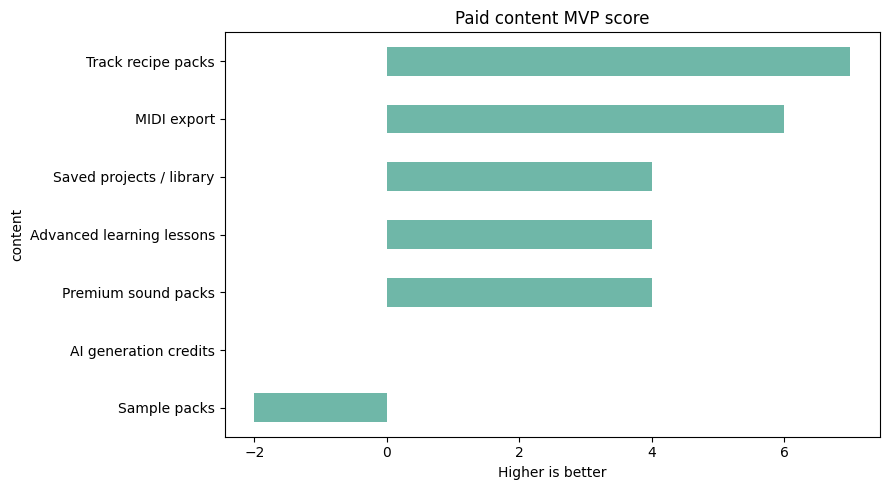

In [5]:
ax = content_options.sort_values('mvp_score').plot.barh(x='content', y='mvp_score', legend=False, figsize=(9, 5), color='#6fb7a8')
ax.set_title('Paid content MVP score')
ax.set_xlabel('Higher is better')
plt.tight_layout()
plt.savefig(fig_dir / 'paid-content-mvp-score.png', dpi=160)
plt.show()


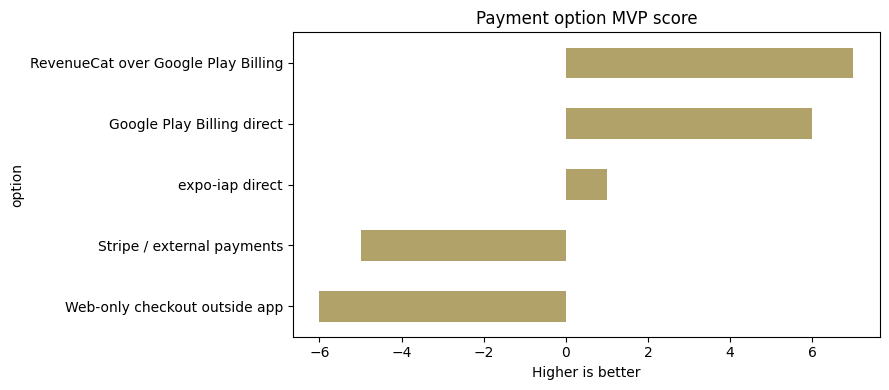

In [6]:
ax = payment_options.sort_values('mvp_score').plot.barh(x='option', y='mvp_score', legend=False, figsize=(9, 4), color='#b1a269')
ax.set_title('Payment option MVP score')
ax.set_xlabel('Higher is better')
plt.tight_layout()
plt.savefig(fig_dir / 'payment-option-mvp-score.png', dpi=160)
plt.show()


## Decision Summary

Recommendation: **Narrow**.

Do not start with a broad paid-content system or external payment strategy. Start with a single Google Play-compliant paid entitlement after the free workflow proves retention.

Recommended MVP paid content:

1. Free app remains useful: core vibe selection, playable preview, MIDI screen, basic learning.
2. One-time Pro unlock via Google Play Billing / RevenueCat:
   - MIDI export when available.
   - Expanded track recipe packs: more dub techno moods, seasonal contexts, performance-focused variations.
   - Advanced learning modules: chord color, bass movement, stab timing, space/delay listening.
   - Saved favorites / project recall if implementation cost stays low.
3. Defer subscription until there is ongoing value:
   - cloud sync,
   - frequent new packs,
   - AI generation with real operating costs,
   - or creator/community content.
4. Defer external checkout:
   - Google Play requires Play Billing for in-app digital goods by default.
   - External payments are region/program dependent and require enrollment, required UX, reporting, and backend work.
   - Stripe can be considered later only after legal/policy verification for target regions.

Evidence:

- Google Play policy strongly favors Play Billing for in-app digital goods.
- Expo recommends native IAP via development builds; RevenueCat is a practical integration path.
- Adjacent tools monetize MIDI export, chord workflows, large libraries, and Pro features.
- Vibe-to-MIDI's differentiator is not generic content volume; it is DAW-ready mood-to-note/sound guidance.

Risks:

- Policy risk if external payment links are shown without eligibility/enrollment.
- Low willingness to pay before DAW export or saved workflow exists.
- Subscription backlash if paid value is static content only.
- Licensing risk if paid content uses samples, loops, or style references.
- Support burden from purchase restore, refunds, entitlement bugs, and offline access.

Next step:

Build a free-to-Pro entitlement design document before implementation. Define exactly which screens/features are free, which are Pro, and which product IDs are needed in Play Console.

## Open Questions

- Which retention signal should be required before adding billing: sessions per user, repeated MIDI screen use, or save/export attempts?
- Is MIDI export already stable enough to be the primary paid feature, or should Pro launch with recipe packs first?
- Should paid packs be genre-pure Dub Techno only, or expand to adjacent ambient/minimal styles?
- Will the first release be Google Play only, or should web/iOS purchase portability influence the entitlement system now?
- Should RevenueCat be accepted as infrastructure dependency, or should the project implement direct Play Billing plus backend later?
- Does the app need account login for purchase restore across devices, or can store restore be enough for MVP?
- Which regions are launch targets for paid features: Japan, US, global Google Play, or staged rollout?